# Veri Görselleştirme ve Analiz
Bu bölümde, temizlenmiş veri seti üzerinden mevsimsellik, ilçe bazlı tüketim farkları ve müşteri segmentasyonu analizleri yapılacaktır.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Gereksiz uyarıları kapatma
warnings.filterwarnings('ignore')

# Grafiklerin genel stil ayarları
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Temizlenmiş veriyi yükleme
# Hata alırsanız notebook_01 dosyasını çalıştırdığınızdan emin olun
try:
    df = pd.read_csv('temiz_tuketim_verisi.csv')
    print("Veri seti başarıyla yüklendi.")
    print(f"Toplam kayıt sayısı: {len(df)}")
except FileNotFoundError:
    print("Dosya bulunamadı. Lütfen önce veri keşfi notebook'unu çalıştırın.")

Veri seti başarıyla yüklendi.
Toplam kayıt sayısı: 1185547


## Mevsimsel Tüketim Trendi
Aylık ortalama tüketim verileri incelenerek mevsimsel dalgalanmalar analiz edilmiştir.

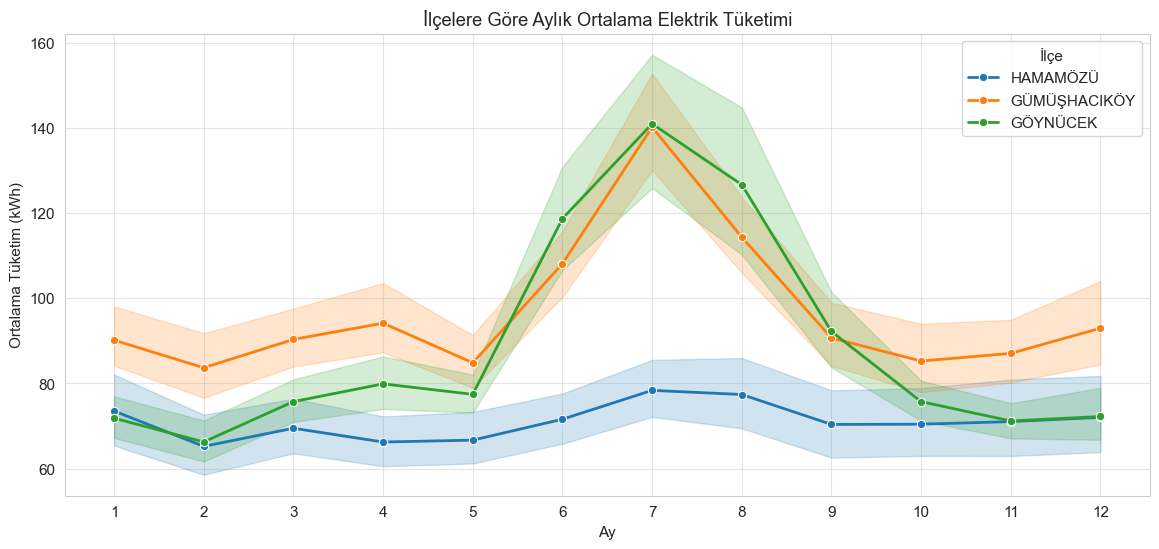

In [3]:
plt.figure(figsize=(14, 6))

# Aylara ve ilçelere göre gruplayarak çizgi grafik oluşturma
sns.lineplot(data=df, x='ay', y='kwh', hue='ilce', marker='o', linewidth=2)

plt.title('İlçelere Göre Aylık Ortalama Elektrik Tüketimi')
plt.xlabel('Ay')
plt.ylabel('Ortalama Tüketim (kWh)')
plt.xticks(range(1, 13)) # X ekseninde 1-12 arası ayları göster
plt.legend(title='İlçe')
plt.grid(True, alpha=0.5)

plt.show()

## İlçe Bazlı Tüketim Karşılaştırması
İlçelerin ortalama elektrik tüketim değerlerinin karşılaştırılması.

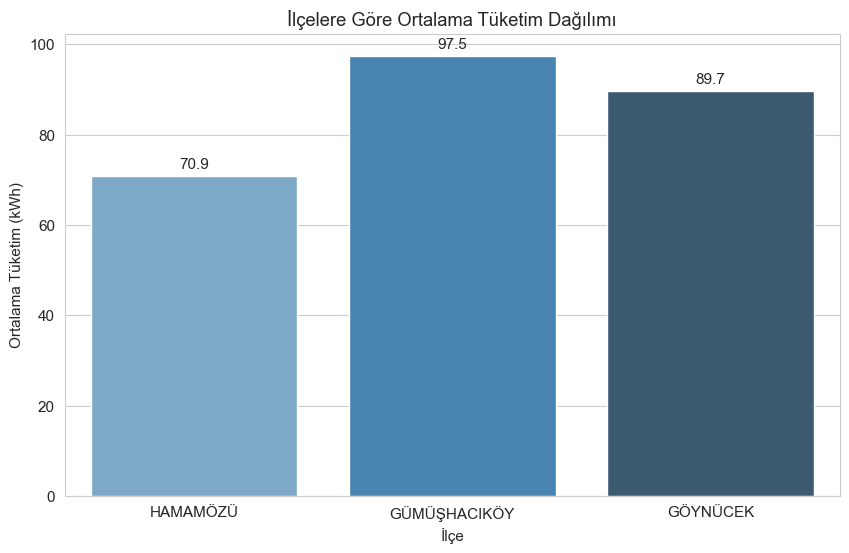

In [4]:
plt.figure(figsize=(10, 6))

# İlçe bazında ortalama tüketimi gösteren sütun grafiği
ax = sns.barplot(data=df, x='ilce', y='kwh', errorbar=None, palette='Blues_d')

plt.title('İlçelere Göre Ortalama Tüketim Dağılımı')
plt.xlabel('İlçe')
plt.ylabel('Ortalama Tüketim (kWh)')

# Çubukların üzerine değerleri yazdırma
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.show()

## Müşteri Segmentasyonu
En yüksek tüketim ortalamasına sahip hesap sınıflarının (abone tiplerinin) incelenmesi.

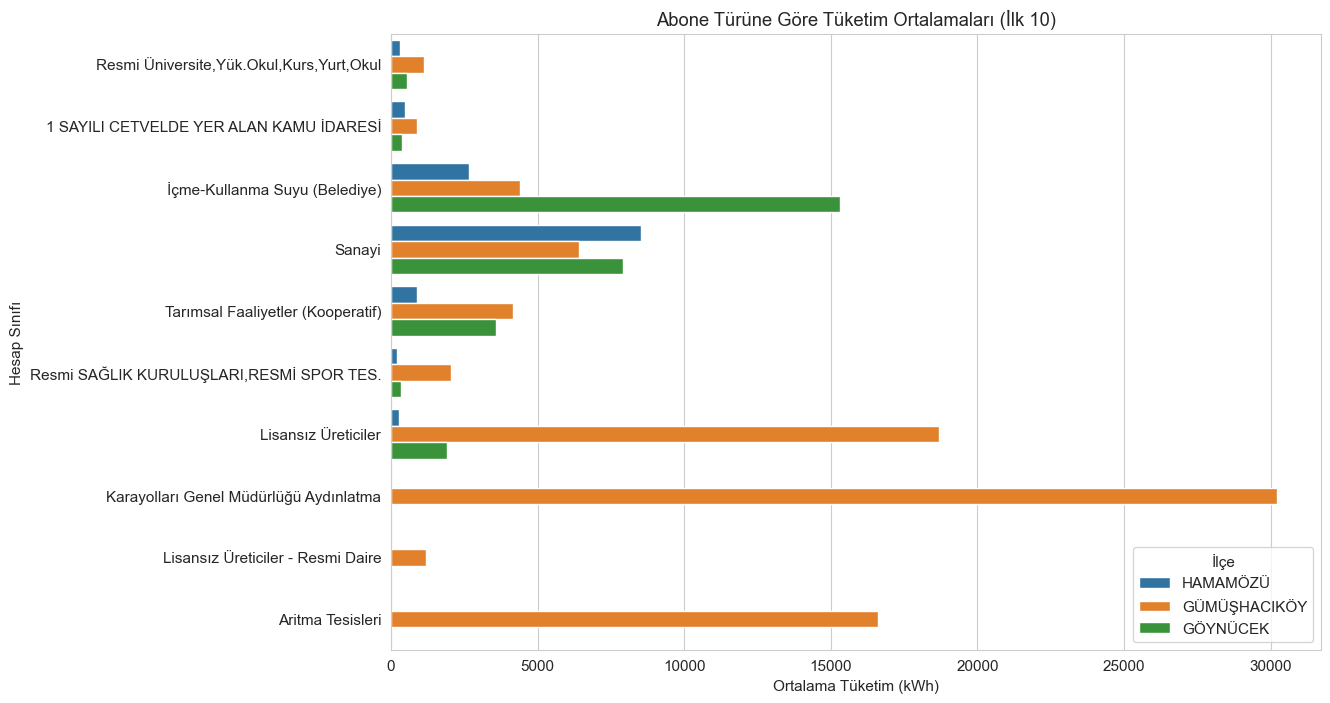

In [5]:
plt.figure(figsize=(12, 8))

# En çok tüketim yapan 10 hesap sınıfını belirleme
en_yuksek_siniflar = df.groupby('Hesap Sınıfı')['kwh'].mean().sort_values(ascending=False).head(10).index
df_filtreli = df[df['Hesap Sınıfı'].isin(en_yuksek_siniflar)]

# Yatay sütun grafiği ile gösterim
sns.barplot(data=df_filtreli, y='Hesap Sınıfı', x='kwh', hue='ilce', errorbar=None)

plt.title('Abone Türüne Göre Tüketim Ortalamaları (İlk 10)')
plt.xlabel('Ortalama Tüketim (kWh)')
plt.ylabel('Hesap Sınıfı')
plt.legend(title='İlçe', loc='lower right')

plt.show()

## Tüketim Dağılımı ve Aykırı Değer Analizi
Tüketim verisindeki yayılımı ve standart dışı (aykırı) değerleri gözlemlemek için kutu grafiği analizi.

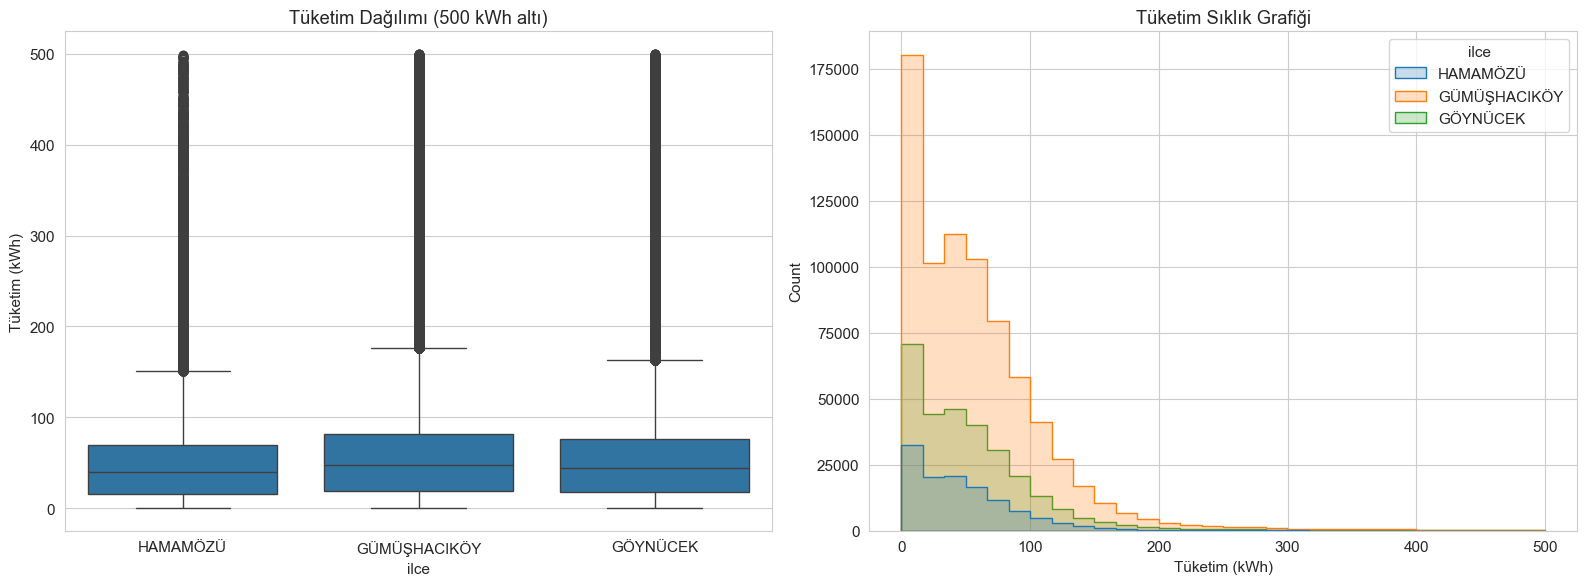

In [6]:
# Grafiği iki parçaya bölüyoruz: Kutu Grafiği ve Histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kutu Grafiği (Box Plot) - 500 kWh altı verilere odaklanıldı
sns.boxplot(data=df[df['kwh'] < 500], x='ilce', y='kwh', ax=axes[0])
axes[0].set_title('Tüketim Dağılımı (500 kWh altı)')
axes[0].set_ylabel('Tüketim (kWh)')

# Histogram - Tüketim sıklığı
sns.histplot(data=df[df['kwh'] < 500], x='kwh', hue='ilce', element="step", bins=30, ax=axes[1])
axes[1].set_title('Tüketim Sıklık Grafiği')
axes[1].set_xlabel('Tüketim (kWh)')

plt.tight_layout()
plt.show()

## Ödeme Performansı Analizi
Müşterilerin fatura ödeme alışkanlıklarının (zamanında vs. geç ödeme) oransal dağılımı.

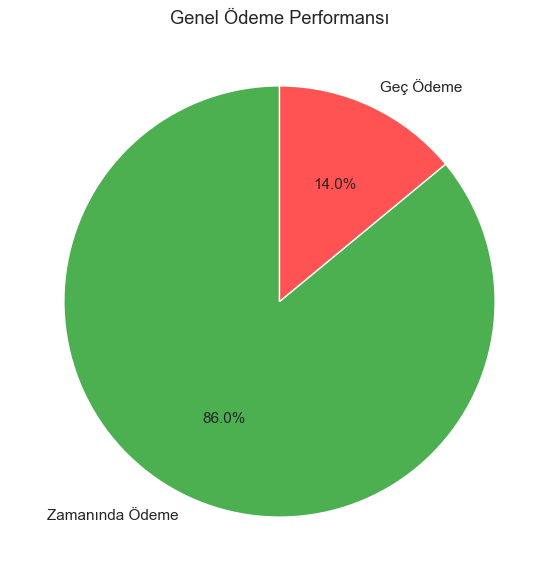

In [7]:
# Vaka çalışması verilerine dayalı oranlar
etiketler = ['Zamanında Ödeme', 'Geç Ödeme']
oranlar = [86, 14] # %86 zamanında, %14 geç ödeme
renkler = ['#4CAF50', '#FF5252'] # Yeşil ve Kırmızı tonları

plt.figure(figsize=(7, 7))
plt.pie(oranlar, labels=etiketler, autopct='%1.1f%%', colors=renkler, startangle=90)

plt.title('Genel Ödeme Performansı')
plt.show()